In [ ]:
!pip install sklearn.model
!pip install catboost

In [ ]:
import catboost
import re
from google.colab import files # Для работы с файлами
import numpy as np # Для работы с данными
import pandas as pd # Для работы с таблицами
import matplotlib.pyplot as plt # Для вывода графиков
import os # Для работы с файлами
%matplotlib inline
from catboost import CatBoostClassifier
from catboost import Pool
from tensorflow.keras import utils # Для работы с категориальными данными
from tensorflow.keras.models import Sequential # Полносвязная модель
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation # Слои для сети
from tensorflow.keras.preprocessing.text import Tokenizer # Методы для работы с текстами и преобразования их в последовательности
from tensorflow.keras.preprocessing.sequence import pad_sequences # Метод для работы с последовательностями

from sklearn.preprocessing import LabelEncoder # Метод кодирования тестовых лейблов
from sklearn.model_selection import train_test_split # Для разделения выборки на тестовую и обучающую
from google.colab import drive # Для работы с Google Drive
import time # Импортируем библиотеку time
from sklearn.metrics import accuracy_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
training = pd.read_csv('/content/drive/MyDrive/тональность отзывов банков/train.csv', on_bad_lines='skip', sep='\t') #читаем файл

In [ ]:
training = training.drop('idx', axis=1)

In [ ]:
text_features = ['Text']
training['text_length'] = training['Text'].apply(len)
training = training.sort_values(by='text_length', ascending=True).reset_index(drop=True)
training[:10]

,Score,Text,text_length
0,Negative,Делают карту VISA почти 3 недели...,35
1,Positive,Все быстро и хорошо. Имею там два кредита. Все...,56
2,Positive,"MasterCard сделали быстро, на все вопросы отве...",62
3,Positive,Сижу в Германии с кредитками Альфа-Банк - Эксп...,73
4,Positive,Оформил кредит на автомобиль.Никаких замечаний...,77
5,Positive,"Был в Сущевском отделении. Тихо, спокойно, нар...",77
6,Positive,Пользуюсь отделением на Тверской. В очередях н...,78
7,Positive,Услугами банка пользуюсь с 2003 года.Очень дов...,80
8,Positive,Отличное знание дела. Брал потребительский кр...,95
9,Positive,"Открыли филиал в Питере, принёс им небольшой в...",95


In [ ]:
def remove_email(x):
     return re.sub(r'([a-z0-9+._-]+@[a-z0-9+._-]+\.[a-z0-9+_-]+)',"", x)

def remove_urls(x):
    return re.sub(r'(http|https|ftp|ssh)://([\w_-]+(?:(?:\.[\w_-]+)+))([\w.,@?^=%&:/~+#-]*[\w@?^=%&/~+#-])?', '' , x)

def remove_rt(x):
    return re.sub(r'\brt\b', '', x).strip()

def remove_special_chars(x):
    x = re.sub(r'[^\w ]+', "", x)
    x = ' '.join(x.split())
    return x

In [ ]:
# удаляем лишние символы
training.Text = training.Text.apply(lambda x: remove_email(x))
training.Text = training.Text.apply(lambda x: remove_urls(x))
training.Text = training.Text.apply(lambda x: remove_rt(x))
training.Text = training.Text.apply(lambda x: remove_special_chars(x))

In [ ]:
x = training.drop('Score', axis=1)

In [ ]:
y = training.drop('Text', axis=1)

In [ ]:
x_training, x_test, y_training, y_test = train_test_split(x, y, test_size=0.3)

In [ ]:
# Создаем пулы для train и validation
train_pool = Pool(x_training, y_training, text_features=text_features)
val_pool = Pool(x_test, y_test, text_features=text_features)

# Обучаем с сохранением истории
model = CatBoostClassifier(
    iterations=500,
    eval_metric='Accuracy',
    verbose=50,
    use_best_model=True
)

In [ ]:
model.fit(train_pool, eval_set=val_pool)

Learning rate set to 0.07528
0:	learn: 0.9259108	test: 0.9333333	best: 0.9333333 (0)	total: 293ms	remaining: 2m 26s
50:	learn: 0.9364221	test: 0.9435714	best: 0.9438095 (45)	total: 15.1s	remaining: 2m 12s
100:	learn: 0.9443821	test: 0.9471429	best: 0.9471429 (99)	total: 29.7s	remaining: 1m 57s
150:	learn: 0.9500969	test: 0.9480952	best: 0.9485714 (137)	total: 45.4s	remaining: 1m 44s
200:	learn: 0.9563221	test: 0.9500000	best: 0.9502381 (197)	total: 60s	remaining: 1m 29s
250:	learn: 0.9623431	test: 0.9504762	best: 0.9509524 (239)	total: 1m 14s	remaining: 1m 14s
300:	learn: 0.9675477	test: 0.9514286	best: 0.9514286 (286)	total: 1m 29s	remaining: 59.4s
350:	learn: 0.9719359	test: 0.9521429	best: 0.9523810 (346)	total: 1m 44s	remaining: 44.4s
400:	learn: 0.9765282	test: 0.9521429	best: 0.9526190 (378)	total: 1m 59s	remaining: 29.5s
450:	learn: 0.9806103	test: 0.9526190	best: 0.9526190 (378)	total: 2m 14s	remaining: 14.6s
499:	learn: 0.9827533	test: 0.9521429	best: 0.9528571 (454)	total: 2m

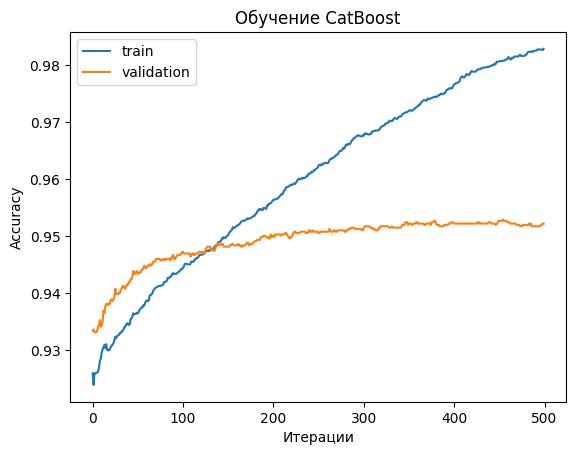

In [ ]:
history = model.get_evals_result()

# Строим график
plt.plot(history['learn']['Accuracy'], label='train')
plt.plot(history['validation']['Accuracy'], label='validation')
plt.xlabel("Итерации")
plt.ylabel("Accuracy")
plt.title("Обучение CatBoost")
plt.legend()
plt.show()

In [ ]:
#test = pd.read_csv('/content/drive/MyDrive/тональность отзывов банков/test.csv', on_bad_lines='skip', sep='\t') #читаем файл

In [ ]:
#test

In [ ]:
#x_pred = test.drop('idx', axis=1) # удаляем 'idx'

In [ ]:
#y_pred = model.predict(x_pred) # предиктим

In [ ]:
#y_pred

In [ ]:
#test['Text'] = y_pred

In [ ]:
#test = test.rename({'Text': 'Score'}, axis=1) # переименовываем

In [ ]:
#test

In [ ]:
#test.to_csv('/content/drive/MyDrive/тональность отзывов банков/sample_submission.csv', sep='\t') #загружаем данные теста в файл